In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# URL for Titanic Dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)

In [3]:
df.shape

(891, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 116.9 KB


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
features = ['age', 'fare', 'sibsp', 'parch', 'pclass']

data = df[features]

print("Selected Features = ", features)
data.head()

Selected Features =  ['age', 'fare', 'sibsp', 'parch', 'pclass']


,age,fare,sibsp,parch,pclass
0,22.0,7.2500,1,0,3
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,3
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,3


In [7]:
data.isnull().sum()

age       177
fare        0
sibsp       0
parch       0
pclass      0
dtype: int64

In [8]:
data.dropna(inplace=True)
data.isnull().sum()

age       0
fare      0
sibsp     0
parch     0
pclass    0
dtype: int64

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(data)

X_scaled[:5]

array([[-0.53037664, -0.51897787,  0.52457013, -0.50589515,  0.91123237],
       [ 0.57183099,  0.69189675,  0.52457013, -0.50589515, -1.47636364],
       [-0.25482473, -0.50621356, -0.55170307, -0.50589515,  0.91123237],
       [ 0.36516706,  0.34804915,  0.52457013, -0.50589515, -1.47636364],
       [ 0.36516706, -0.5038498 , -0.55170307, -0.50589515,  0.91123237]])

In [10]:
X_scaled.shape

(714, 5)

In [11]:
# Convert standardized data into a DataFrame for better visualization

scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

scaled_df.head()

,age,fare,sibsp,parch,pclass
0,-0.530377,-0.518978,0.524570,-0.505895,0.911232
1,0.571831,0.691897,0.524570,-0.505895,-1.476364
2,-0.254825,-0.506214,-0.551703,-0.505895,0.911232
3,0.365167,0.348049,0.524570,-0.505895,-1.476364
4,0.365167,-0.503850,-0.551703,-0.505895,0.911232


In [12]:
scaled_df.mean()

age       2.338621e-16
fare     -5.970947e-17
sibsp    -4.975789e-18
parch    -7.214895e-17
pclass   -5.473368e-17
dtype: float64

In [13]:
scaled_df.std()

age       1.000701
fare      1.000701
sibsp     1.000701
parch     1.000701
pclass    1.000701
dtype: float64

In [14]:
# Apply PCA with 2 components

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca[:5]

array([[ 1.13304515, -0.42033868],
       [-1.46088783,  0.65499926],
       [ 0.6419752 , -1.04899915],
       [-1.20360566,  0.51464182],
       [ 0.30251589, -1.1700154 ]])

In [15]:
X_pca.shape

(714, 2)

In [16]:
# Display explained variance ratio

explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
for i, variance in enumerate(explained_variance, start=1):
    print(f"PC{i} = {variance:.4f} ({variance * 100:.2f}%)")

Explained Variance Ratio:
PC1 = 0.3483 (34.83%)
PC2 = 0.3227 (32.27%)


In [17]:
# Calculate total explained variance

total_variance = explained_variance.sum()

print(f"Total Explained Variance = {total_variance:.4f}")
print(f"Total Explained Variance = {total_variance * 100:.2f}%")

Total Explained Variance = 0.6710
Total Explained Variance = 67.10%


In [18]:
# Create DataFrame containing principal components

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df.head()

,PC1,PC2
0,1.133045,-0.420339
1,-1.460888,0.654999
2,0.641975,-1.048999
3,-1.203606,0.514642
4,0.302516,-1.170015


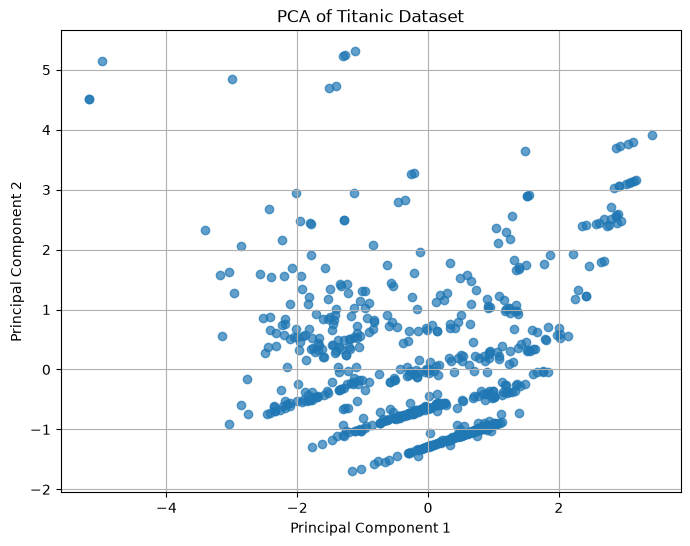

In [19]:
# Plot the first two principal components

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Titanic Dataset")

plt.grid(True)
plt.show()

In [20]:
# Apply PCA with 3 components

pca_3 = PCA(n_components=3)

X_pca_3 = pca_3.fit_transform(X_scaled)

print("Shape before PCA = ", X_scaled.shape)
print("Shape after PCA = ", X_pca_3.shape)

print("\nExplained Variance Ratio = ")

for i, variance in enumerate(pca_3.explained_variance_ratio_, start=1):
    print(f"PC{i} = {variance:.4f} ({variance * 100:.2f}%)")

print("\nTotal Explained Variance = ")
print(
    f"{pca_3.explained_variance_ratio_.sum():.4f} "
    f"({pca_3.explained_variance_ratio_.sum() * 100:.2f}%)"
)


Shape before PCA =  (714, 5)
Shape after PCA =  (714, 3)

Explained Variance Ratio = 
PC1 = 0.3483 (34.83%)
PC2 = 0.3227 (32.27%)
PC3 = 0.1382 (13.82%)

Total Explained Variance = 
0.8092 (80.92%)


In [21]:
# Apply PCA with all components

pca_all = PCA(n_components=5)

X_pca_all = pca_all.fit_transform(X_scaled)

explained_variance_all = pca_all.explained_variance_ratio_

print("Explained Variance Ratio = ")

for i, variance in enumerate(explained_variance_all, start=1):
    print(f"PC{i} = {variance:.4f} ({variance * 100:.2f}%)")

Explained Variance Ratio = 
PC1 = 0.3483 (34.83%)
PC2 = 0.3227 (32.27%)
PC3 = 0.1382 (13.82%)
PC4 = 0.1180 (11.80%)
PC5 = 0.0728 (7.28%)


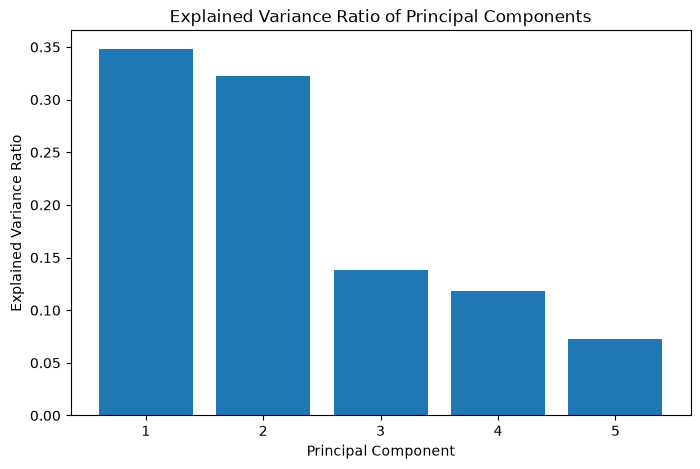

In [22]:
# Plot explained variance ratio

plt.figure(figsize=(8, 5))

components = range(1, 6)

plt.bar(
    components,
    explained_variance_all
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio of Principal Components")

plt.xticks(components)

plt.show()

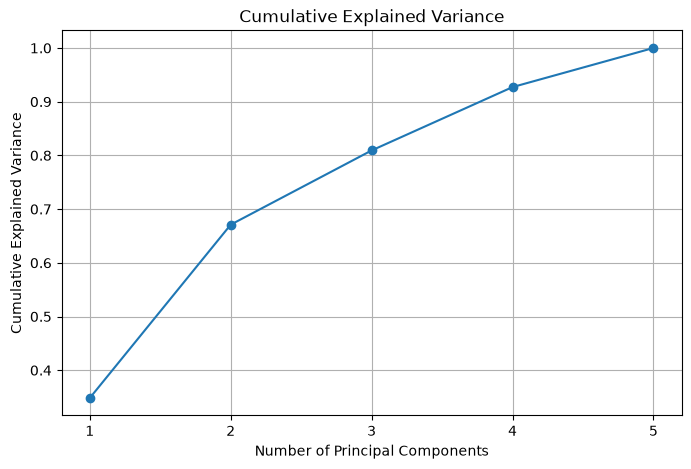

In [23]:
# Plot cumulative explained variance

cumulative_variance = np.cumsum(explained_variance_all)

plt.figure(figsize=(8, 5))

plt.plot(
    components,
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.xticks(components)
plt.grid(True)

plt.show()

In [24]:
# Compare dimensions before and after PCA

print("Before PCA:")
print("Number of samples:", X_scaled.shape[0])
print("Number of features:", X_scaled.shape[1])

print("\nAfter PCA:")
print("Number of samples:", X_pca.shape[0])
print("Number of components:", X_pca.shape[1])

Before PCA:
Number of samples: 714
Number of features: 5

After PCA:
Number of samples: 714
Number of components: 2


In [25]:
# Display PCA transformed data

print("PCA Transformed Data:")
display(pca_df.head())

PCA Transformed Data:


,PC1,PC2
0,1.133045,-0.420339
1,-1.460888,0.654999
2,0.641975,-1.048999
3,-1.203606,0.514642
4,0.302516,-1.170015


In [26]:
# Calculate PCA loadings

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)

loadings

,PC1,PC2
age,-0.545920,-0.197198
fare,-0.420128,0.526719
sibsp,0.311517,0.539868
parch,0.205828,0.563015
pclass,0.621333,-0.274293


In [27]:
# Display the contribution of each feature using absolute loadings

absolute_loadings = loadings.abs()

print("Absolute PCA Loadings:")
display(absolute_loadings)

Absolute PCA Loadings:


,PC1,PC2
age,0.545920,0.197198
fare,0.420128,0.526719
sibsp,0.311517,0.539868
parch,0.205828,0.563015
pclass,0.621333,0.274293


In [28]:
from sklearn.datasets import load_iris

# Load Iris dataset

iris = load_iris()

X_iris = iris.data
y_iris = iris.target

print("Original Iris dataset shape:", X_iris.shape)

Original Iris dataset shape: (150, 4)


In [29]:
# Standardize Iris data

scaler_iris = StandardScaler()

X_iris_scaled = scaler_iris.fit_transform(X_iris)

# Apply PCA

pca_iris = PCA(n_components=2)

X_iris_pca = pca_iris.fit_transform(X_iris_scaled)

print("Shape before PCA:", X_iris_scaled.shape)
print("Shape after PCA:", X_iris_pca.shape)

Shape before PCA: (150, 4)
Shape after PCA: (150, 2)


In [30]:
# Display explained variance for Iris dataset

print("Explained Variance Ratio:")

for i, variance in enumerate(
    pca_iris.explained_variance_ratio_,
    start=1
):
    print(f"PC{i}: {variance:.4f} ({variance * 100:.2f}%)")

print("\nTotal Explained Variance:")
print(
    f"{pca_iris.explained_variance_ratio_.sum():.4f} "
    f"({pca_iris.explained_variance_ratio_.sum() * 100:.2f}%)"
)

Explained Variance Ratio:
PC1: 0.7296 (72.96%)
PC2: 0.2285 (22.85%)

Total Explained Variance:
0.9581 (95.81%)


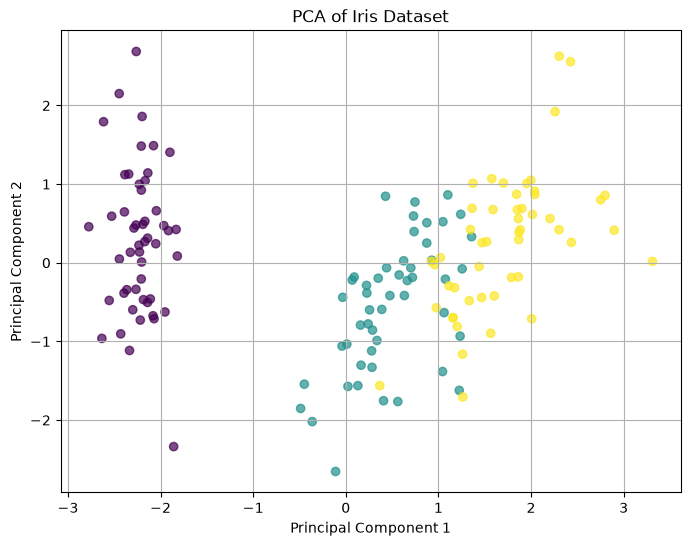

In [31]:
# Visualize Iris PCA

plt.figure(figsize=(8, 6))

plt.scatter(
    X_iris_pca[:, 0],
    X_iris_pca[:, 1],
    c=y_iris,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Iris Dataset")

plt.grid(True)
plt.show()